# Calculus of Variations

In the previous notebook, the decision variable was a finite-dimensional vector:

$$
z \in \mathbb{R}^n.
$$

We now consider problems where the decision variable is an entire function or trajectory:

$$
x(t).
$$

The objective therefore becomes a **functional**:

$$
J[x]=
\int_{t_0}^{t_f}
L(x(t), \dot{x}(t), t)\,dt.
$$

The goal of this notebook is to understand computationally how optimizing a trajectory differs from ordinary parameter optimization, and how the Euler–Lagrange condition characterizes an optimal trajectory.

# Calculus of Variations

In the previous notebook, the decision variable was a finite-dimensional vector:

$$
z \in \mathbb{R}^n.
$$

We now consider problems where the decision variable is an entire function or trajectory:

$$
x(t).
$$

The objective therefore becomes a **functional**:

$$
J[x]=
\int_{t_0}^{t_f}
L(x(t), \dot{x}(t), t)\,dt.
$$

The goal of this notebook is to understand computationally how optimizing a trajectory differs from ordinary parameter optimization, and how the Euler–Lagrange condition characterizes an optimal trajectory.

## 1. Minimum-Energy Trajectory

### Requirement

Find a smooth trajectory connecting

$$
x(0)=0
$$

to

$$
x(1)=1
$$

while minimizing the amount of variation along the trajectory.

### Formulation

$$
\min_{x(\cdot)}
J[x]=
\frac12
\int_0^1
\dot{x}(t)^2\,dt
$$

subject to

$$
x(0)=0,
\qquad
x(1)=1.
$$

### Components

- **Decision variable:** trajectory $x(t)$
- **Functional:** $J[x]$
- **Boundary conditions:** $x(0)=0,\;x(1)=1$
- **Integrand:** $L(x,\dot{x},t)=\frac12\dot{x}^2$

In [27]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

N=50

t = jnp.linspace(0.0, 1.0, N+1)
dt=t[1] - t[0]

In [28]:
def trajectory_cost(x, dt):
    x_dot = jnp.diff(x) / dt
    return 0.5 * jnp.sum(x_dot**2) * dt

In [29]:
x_start = 0.0
x_goal = 1.0


def build_trajectory(x_interior):
    return jnp.concatenate([
        jnp.array([x_start]),
        x_interior,
        jnp.array([x_goal]),
    ])


def objective_interior(x_interior):
    x = build_trajectory(x_interior)
    return trajectory_cost(x, dt)

In [30]:
key = jax.random.PRNGKey(0)

x_initial = jnp.linspace(
    x_start,
    x_goal,
    N + 1,
)

noise = 0.15 * jax.random.normal(
    key,
    shape=(N - 1,),
)

x_interior = x_initial[1:-1] + noise

initial_trajectory = build_trajectory(x_interior)

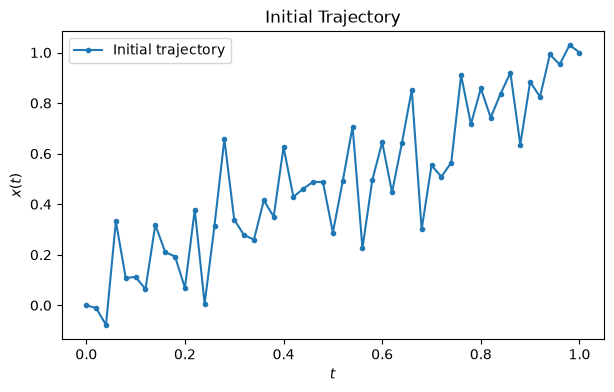

In [31]:
plt.figure(figsize=(7, 4))

plt.plot(t, x0, marker=".", label="Initial trajectory")

plt.xlabel("$t$")
plt.ylabel("$x(t)$")
plt.title("Initial Trajectory")
plt.legend()
plt.show()

In [32]:
grad_cost = jax.grad(objective_interior)

In [33]:
def gradient_step(x_interior, step_size):
    grad = grad_cost(x_interior)
    return x_interior - step_size * grad

In [34]:
def optimize_trajectory(x_interior, step_size, num_steps):
    x = x_interior
    cost_history = []

    for _ in range(num_steps):
        cost_history.append(objective_interior(x))
        x = gradient_step(x, step_size)

    cost_history.append(objective_interior(x))

    return x, jnp.stack(cost_history)

In [35]:
x_interior_opt, cost_history = optimize_trajectory(
    x_interior=x_interior,
    step_size=1e-4,
    num_steps=3000,
)

optimized_trajectory = build_trajectory(x_interior_opt)

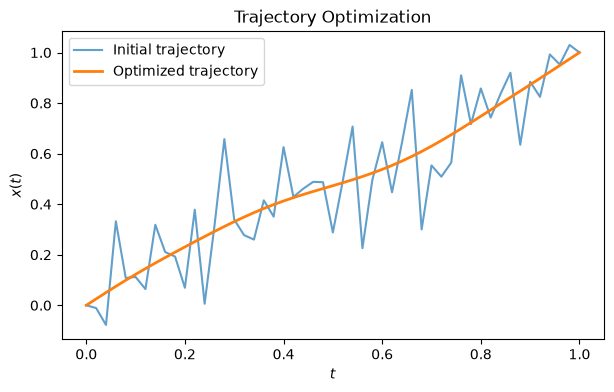

In [36]:
plt.figure(figsize=(7, 4))

plt.plot(
    t,
    initial_trajectory,
    label="Initial trajectory",
    alpha=0.7,
)

plt.plot(
    t,
    optimized_trajectory,
    label="Optimized trajectory",
    linewidth=2,
)

plt.xlabel("$t$")
plt.ylabel("$x(t)$")
plt.title("Trajectory Optimization")
plt.legend()
plt.show()

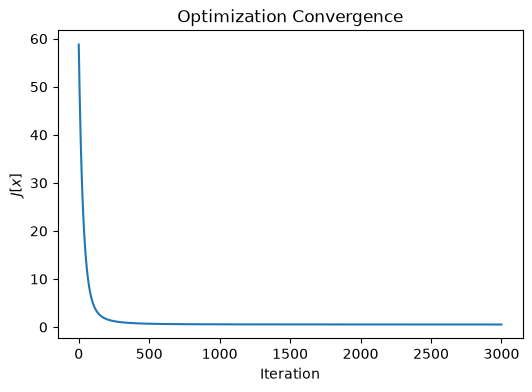

In [37]:
plt.figure(figsize=(6, 4))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("$J[x]$")
plt.title("Optimization Convergence")
plt.show()

## 2. Euler–Lagrange Condition

Our trajectory optimization problem is

$$
\min_{x(\cdot)}
J[x]=
\int_0^1 L(x,\dot{x},t)\,dt
$$

with

$$
L(x,\dot{x},t)
=\frac12\dot{x}^2.
$$

For a stationary trajectory, the Euler–Lagrange equation is

$$
\frac{\partial L}{\partial x}-
\frac{d}{dt}
\left(
\frac{\partial L}{\partial \dot{x}}
\right)
=0.
$$

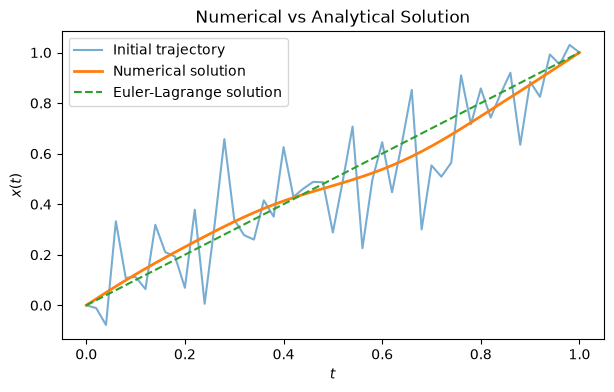

In [38]:
x_analytical = t

plt.figure(figsize=(7, 4))

plt.plot(
    t,
    initial_trajectory,
    label="Initial trajectory",
    alpha=0.6,
)

plt.plot(
    t,
    optimized_trajectory,
    label="Numerical solution",
    linewidth=2,
)

plt.plot(
    t,
    x_analytical,
    "--",
    label="Euler-Lagrange solution",
)

plt.xlabel("$t$")
plt.ylabel("$x(t)$")
plt.title("Numerical vs Analytical Solution")
plt.legend()
plt.show()

### Takeaway

Calculus of variations extends optimization from finite-dimensional decision variables to entire functions or trajectories.

For

$$
J[x]=\frac12\int_0^1\dot{x}^2dt,
$$

the Euler–Lagrange condition gives

$$
\ddot{x}=0.
$$

Together with the boundary conditions, this produces

$$
x^\star(t)=t.
$$

The same solution can also be approximated computationally by discretizing the trajectory and optimizing its interior points.

This exposes two complementary viewpoints:

- derive conditions that the continuous optimum must satisfy;
- parameterize the trajectory and optimize it numerically.